# Health study - Del 1 – Grundläggande analys och statistik

- Beskrivande statistik,

- Minst 3 grafer,

- Simulering av sjukdomsandel,

- Konfidensintervall (normalapprox + bootstrap),

- Hypotesprövning med bootstrap (ensidigt: rökare > icke-rökare),

- Korta markdown-tolkningar

In [1]:
# Körs först
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


np.random.seed(42)  # reproducibilitet för hela notebooken

# Läs in data 
df = pd.read_csv("../data/health_study_dataset.csv")

# Snabbt översikt
df.head(), df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


(   id  age sex  height  weight  systolic_bp  cholesterol smoker  disease
 0   1   57   F   168.9    65.8        141.8         4.58     No        0
 1   2   47   M   180.4    95.9        144.8         5.18    Yes        0
 2   3   59   F   169.9    82.2        151.7         6.16     No        0
 3   4   72   M   157.7    93.1        151.0         6.63     No        0
 4   5   46   M   192.6   104.1        144.1         5.21     No        0,
 None)

# 1) Beskrivande statistik
Kodcell: aggregera mean, median, min, max

In [2]:
cols = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']
desc = df[cols].agg(['mean', 'median', 'min', 'max']).T
desc = desc.rename(columns={'mean':'mean', 'median':'median', 'min':'min', 'max':'max'})
desc.style.format("{:.2f}")


,mean,median,min,max
age,49.43,50.00,18.00,90.00
weight,73.41,73.20,33.70,114.40
height,171.85,171.35,144.40,200.40
systolic_bp,149.18,149.40,106.80,185.90
cholesterol,4.93,4.97,2.50,7.88


# (2) Grafer (minst 3)
- 1 Histogram över systoliskt blodtryck

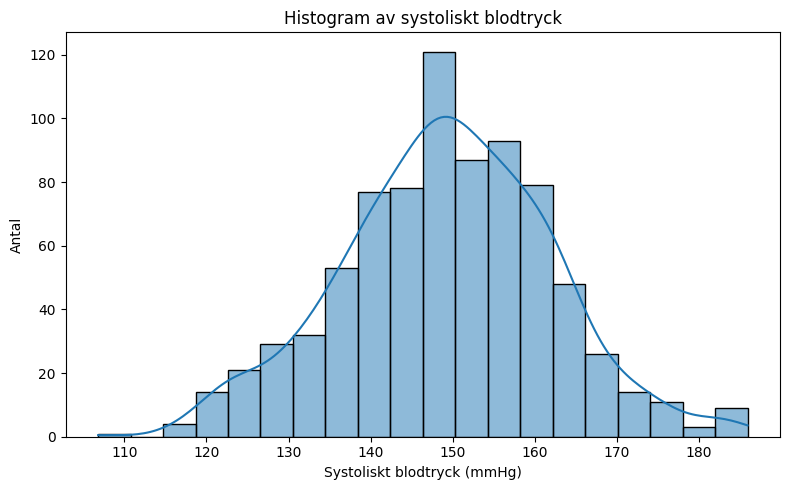

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['systolic_bp'].dropna(), bins=20, kde=True)
plt.title("Histogram av systoliskt blodtryck")
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal")
plt.tight_layout()
plt.show()


2 Boxplot vikt per kön

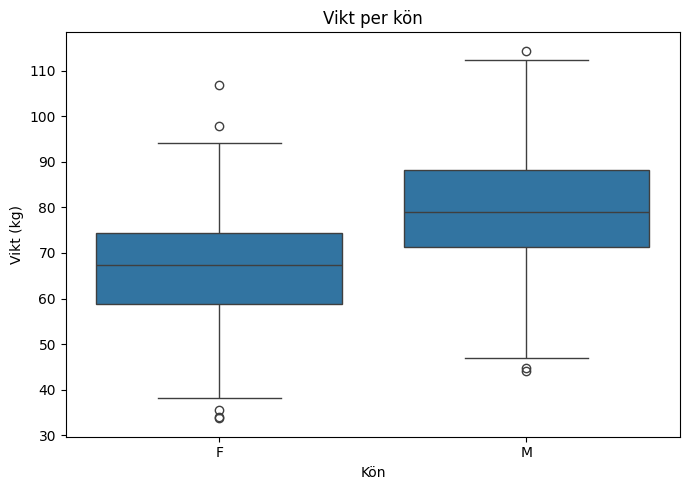

In [4]:
plt.figure(figsize=(7,5))
sns.boxplot(x='sex', y='weight', data=df)
plt.title("Vikt per kön")
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.tight_layout()
plt.show()


3 Stapeldiagram andel rökare

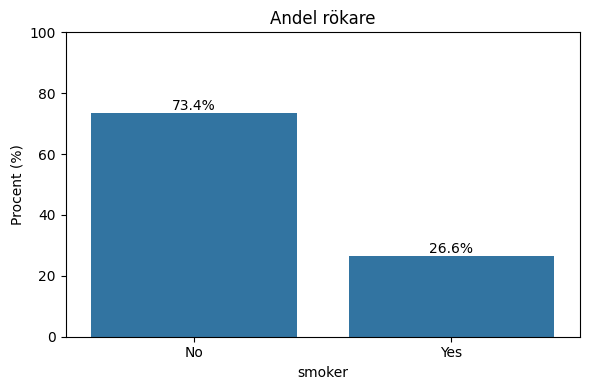

In [5]:
plt.figure(figsize=(6,4))
smoke_pct = df['smoker'].value_counts(normalize=True).mul(100).rename_axis('smoker').reset_index(name='pct')
sns.barplot(x='smoker', y='pct', data=smoke_pct)
plt.ylabel("Procent (%)")
plt.title("Andel rökare")
plt.ylim(0,100)
for i, v in enumerate(smoke_pct['pct']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()


# Simulering kopplad till caset (1000 personer)

In [6]:

# 1. Beräkna verklig andel sjukdom
real_prob = df['disease'].mean()

# 2. Simulera 1000 personer (med seed) med samma sannolikhet för sjukdom
np.random.seed(42)
simulated = np.random.rand(1000) < real_prob
sim_prob = simulated.mean()

# 3. Jämför simulerad andel med verklig andel
print("Verklig andel sjukdom:", real_prob)
print("Simulerad andel sjukdom:", sim_prob)
print("Skillnad:", sim_prob - real_prob)


Verklig andel sjukdom: 0.05875
Simulerad andel sjukdom: 0.063
Skillnad: 0.004250000000000004


# Konfidensintervall

95% bootstrap CI: [148.34, 150.08]


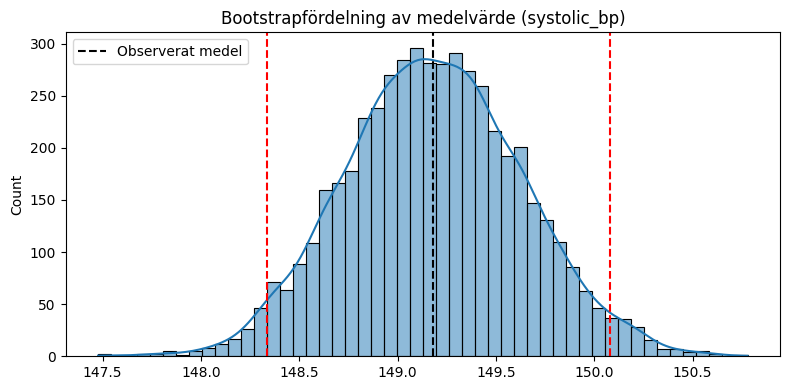

In [7]:
# Bootstrap-konfidensintervall för systoliskt blodtryck
bp = df['systolic_bp'].dropna()
n = len(bp)
mean_bp = bp.mean()

B = 5000
means = np.empty(B)
x = bp.values
for i in range(B):
    sample = np.random.choice(x, size=n, replace=True)
    means[i] = sample.mean()

ci_boot = np.percentile(means, [2.5, 97.5])
print(f"95% bootstrap CI: [{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]")

# Visa bootstrap-fördelningen
plt.figure(figsize=(8,4))
sns.histplot(means, bins=50, kde=True)
plt.axvline(mean_bp, color='black', linestyle='--', label='Observerat medel')
plt.axvline(ci_boot[0], color='red', linestyle='--')
plt.axvline(ci_boot[1], color='red', linestyle='--')
plt.title("Bootstrapfördelning av medelvärde (systolic_bp)")
plt.legend()
plt.tight_layout()
plt.show()


# Hypotesprövning

In [8]:
smokers = df[df['smoker'] == 'Yes']['systolic_bp'].dropna().values
nonsmokers = df[df['smoker'] == 'No']['systolic_bp'].dropna().values

obs_diff = smokers.mean() - nonsmokers.mean()
# Centrera under H0
combined_mean = np.mean(np.concatenate([smokers, nonsmokers]))
smokers_centered = smokers - smokers.mean() + combined_mean
nonsmokers_centered = nonsmokers - nonsmokers.mean() + combined_mean

B = 10000
boot_diffs = np.empty(B)
for i in range(B):
    boot_s = np.random.choice(smokers_centered, size=len(smokers), replace=True)
    boot_n = np.random.choice(nonsmokers_centered, size=len(nonsmokers), replace=True)
    boot_diffs[i] = boot_s.mean() - boot_n.mean()

p_one = np.mean(boot_diffs >= obs_diff)  # ensidigt p-värde
ci_diff = np.percentile(boot_diffs, [2.5, 97.5])  # bootstrap-fördelningen av diff (under H0)

print(f"Observerad skillnad i medel (smokers - nonsmokers): {obs_diff:.3f}")
print(f"Bootstrap p-värde (ensidigt): {p_one:.4f}")
print(f"(Observera: ci_diff nedan är för bootstrapfördelningen under H0)")
print(f"95% percentiler för bootstrap-diff (under H0): [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")


Observerad skillnad i medel (smokers - nonsmokers): 0.472
Bootstrap p-värde (ensidigt): 0.3285
(Observera: ci_diff nedan är för bootstrapfördelningen under H0)
95% percentiler för bootstrap-diff (under H0): [-2.112, 2.057]
